# XGBoost

## Imports

In [1]:
import mlflow
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

from heart_failure.features import get_preprocessor
from sklearn.model_selection import StratifiedKFold
from heart_failure.dataset import split_data
from heart_failure.modeling.models import build_xgboost_pipeline
from heart_failure.modeling.train import optuna_search, xgboost_space
from heart_failure.config.modeling import CV_SPLITS, OPTUNA_N_TRIALS, F_BETA_THRESHOLD
from heart_failure.config.config import INTERIM_DATA_DIR, HEART_DISEASE, SEX
from heart_failure.config.features import TEST_SIZE, RANDOM_STATE, VAL_SIZE, TE_CV
from heart_failure.reports import print_best_params
from heart_failure.modeling.evaluate import (
    get_metrics, log_metrics, optuna_cv_results_to_df, find_best_threshold, find_max_recall_by_pr
)
from heart_failure.modeling.predict import predict_by_threshold
from heart_failure.plots import plot_pr_curve

2026-06-20 14:13:18.645 | INFO     | heart_failure.config.config:<module>:11 - PROJ_ROOT path is: D:\heart_failure


In [2]:
MODEL_NAME = "xgboost"
mlflow.set_experiment(f"heart_failure")

<Experiment: artifact_location='file:D:/heart_failure/notebooks/mlruns/1', creation_time=1781534399229, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1781534399229, lifecycle_stage='active', name='heart_failure', tags={}, trace_location=None, workspace='default'>

In [3]:
df = pd.read_csv(INTERIM_DATA_DIR / "heart.csv")

y = df[HEART_DISEASE]
X = df.drop(columns=[HEART_DISEASE])

X_train, y_train, X_val, y_val, X_test, y_test = split_data(
    X, y, stratify_func=lambda X, y: pd.concat([X[[SEX]], y], axis=1)
)

## Training

In [ ]:
cv = StratifiedKFold(n_splits=TE_CV, shuffle=True, random_state=RANDOM_STATE)
fe_pipeline = get_preprocessor(cv)
study, model = optuna_search(
    X_train,
    y_train,
    model_builder=build_xgboost_pipeline,
    param_space=xgboost_space,
    n_trials=OPTUNA_N_TRIALS,
    n_splits=CV_SPLITS,
    random_state=RANDOM_STATE,
    fe_pipeline=fe_pipeline,
)

In [13]:
print_best_params(study)

Best parameters: {'model__n_estimators': 692, 'model__learning_rate': 0.08155237099546424, 'model__gamma': 1.9522577339959621, 'model__max_depth': 3, 'model__reg_lambda': 0.023207595809703156, 'model__reg_alpha': 0.04572616185240538, 'model__subsample': 0.8773407048883316}
Best score: 0.93706


In [14]:
optuna_cv_results_to_df(study).sort_values(["rank_test_score"]).head()

,params,std_test_score,mean_test_score,split_test_0,split_test_1,split_test_2,split_test_3,split_test_4,rank_test_score
36,"{'model__n_estimators': 692, 'model__learning_...",0.024645,0.937059,0.932305,0.893416,0.940074,0.965695,0.953805,1
32,"{'model__n_estimators': 675, 'model__learning_...",0.023033,0.936604,0.928374,0.899037,0.935510,0.966096,0.954000,2
2,"{'model__n_estimators': 214, 'model__learning_...",0.027546,0.936374,0.925953,0.889509,0.939717,0.966731,0.959960,3
6,"{'model__n_estimators': 702, 'model__learning_...",0.030753,0.935913,0.925262,0.882156,0.942621,0.967578,0.961945,4
33,"{'model__n_estimators': 452, 'model__learning_...",0.022958,0.935718,0.922871,0.900358,0.936109,0.965810,0.953443,5


#### Feature importance

In [17]:
tree = model.named_steps["model"]
pd.Series(tree.feature_importances_, index=fe_pipeline.transform(X).columns).sort_values(ascending=False)

target_encoder__ST_Slope          0.370574
binary_encoder__ExerciseAngina    0.118177
target_encoder__ChestPainType     0.090455
binary_encoder__FastingBS         0.073952
binary_encoder__Sex               0.071457
remainder__Oldpeak                0.058035
binarizer__MaxHR                  0.051512
binarizer__Cholesterol            0.044684
target_encoder__RestingECG        0.042288
remainder__RestingBP              0.040697
binarizer__Age                    0.038169
dtype: float32

### Threshold searching

In [15]:
y_train_proba = model.predict_proba(X_train)[:, 1]
best_threshold = find_best_threshold(y_train, y_train_proba, F_BETA_THRESHOLD)
best_threshold

np.float32(0.381)

## Metrics

In [16]:
print("Train metrics")
y_train_pred = predict_by_threshold(model, X_train, best_threshold)
train_metrics = get_metrics(y_train, y_train_pred, y_train_proba)
train_metrics

Train metrics


precision    0.878238
recall       0.952247
f2_score     0.936464
pr_auc       0.975411
dtype: float64

In [17]:
print("Validate metrics")
y_val_pred = predict_by_threshold(model, X_val, best_threshold)
y_val_proba = model.predict_proba(X_val)[:, 1]
val_metrics = get_metrics(y_val, y_val_pred, y_val_proba)
val_metrics

Validate metrics


precision    0.771930
recall       0.897959
f2_score     0.869565
pr_auc       0.951282
dtype: float64

On train and validate, the pr-auc metrics are better than those of the previous models. However, on validate, recall is poor, indicating a poor choice of threshold.

### Confusion Matrix

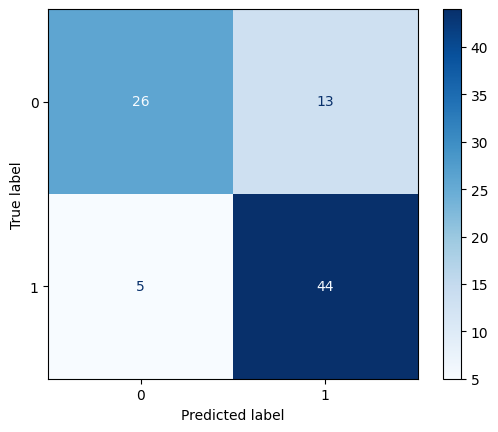

In [21]:
ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred, cmap="Blues")
plt.show()

### PR-curve

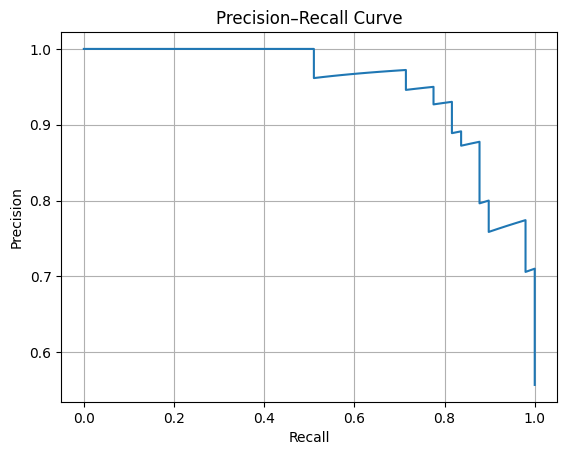

In [22]:
plot_pr_curve(y_val, y_val_proba)

Unlike previous models, here, with recall=1, the precision reaches at least 0.7. Because of this, we can choose a threshold at which recall=1.

In [9]:
best_threshold = find_max_recall_by_pr(y_val, y_val_proba, 1)
round(best_threshold, 3)

np.float32(0.083)

### Test metrics

In [10]:
print("Test metrics")
y_test_pred = predict_by_threshold(model, X_test, best_threshold)
y_test_proba = model.predict_proba(X_test)[:, 1]
test_metrics = get_metrics(y_test, y_test_pred, y_test_proba)
test_metrics

Test metrics


precision    0.708333
recall       1.000000
f2_score     0.923913
pr_auc       0.903401
dtype: float64

Next, I want to consider the following questions:
- Why is the score always worse on split_1 than on the other splits?
- How can the models be improved? What features should be added?
- Comparison of models and their predictions. Do they have the same FN?
- Which model is currently the best?

In [ ]:
cv_results = optuna_cv_results_to_df(study)

with mlflow.start_run(run_name=MODEL_NAME) as run:
    best_cv_result = cv_results.sort_values("rank_test_score").iloc[0].to_dict()
    mlflow.log_dict(best_cv_result, artifact_file="best_cv_result.json")
    for i in range(CV_SPLITS):
        mlflow.log_metric(f"cv_split_{i}_score", best_cv_result[f"split_test_{i}"])

    mlflow.log_param("model", MODEL_NAME)
    mlflow.log_param("test_size", TEST_SIZE)
    mlflow.log_param("val_size", VAL_SIZE)
    mlflow.log_param("random_state", RANDOM_STATE)
    mlflow.log_param("cv_splits", CV_SPLITS)
    mlflow.log_param("optuna_n_trials", OPTUNA_N_TRIALS)
    mlflow.log_param("remaining_columns", "all")
    mlflow.log_param("f_beta_threshold", F_BETA_THRESHOLD)
    mlflow.log_param("proba_threshold", best_threshold)

    mlflow.sklearn.log_model(sk_model=model, name=MODEL_NAME)

    log_metrics(train_metrics, "train_")
    log_metrics(val_metrics, "val_")
    log_metrics(test_metrics, "test_")